# Step 2: Clean, Audit, and Showcase the Fused Flight Dataset
This notebook reviews the cleaning pass applied to the Step 1 master catalog.
It focuses on what was kept, what was dropped, and why the final dataset is safe for downstream work.


## How to Use This Notebook Safely
Use saved outputs for review and flip the build switch only when you want to regenerate Step 2 artifacts.
That keeps the notebook deterministic during demos and final checks.


In [1]:
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML


def resolve_artifact_path(saved_path: str | Path, *, project_root: Path, step1_root: Path | None = None, step2_root: Path | None = None) -> Path:
    candidate = Path(saved_path)
    if candidate.exists():
        return candidate

    parts = candidate.as_posix().split("/")

    if "artifacts" in parts:
        idx = parts.index("artifacts")
        rebuilt = project_root / "artifacts" / Path(*parts[idx + 1:])
        if rebuilt.exists():
            return rebuilt

    if "flights" in parts:
        idx = parts.index("flights")
        suffix = parts[idx:]
        for root in (step2_root, step1_root):
            if root is None:
                continue
            rebuilt = root.joinpath(*suffix)
            if rebuilt.exists():
                return rebuilt

    return candidate


def normalize_path_columns(frame: pd.DataFrame, *, project_root: Path, step1_root: Path | None = None, step2_root: Path | None = None) -> pd.DataFrame:
    if frame.empty:
        return frame
    normalized = frame.copy()
    path_columns = [col for col in normalized.columns if col.endswith("_path")]
    for col in path_columns:
        normalized[col] = normalized[col].map(
            lambda value: str(resolve_artifact_path(value, project_root=project_root, step1_root=step1_root, step2_root=step2_root)) if pd.notna(value) else value
        )
    return normalized

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

import aero_fusion.step2_clean as step2_clean_module
importlib.reload(step2_clean_module)

from aero_fusion.step2_clean import (
    OUTLIER_SPEED_THRESHOLDS_KTS,
    RESAMPLE_SECONDS,
    STANDARD_SECTION_COLUMNS,
    SECTION_FILE_NAMES,
    Step2Config,
    build_step2_clean,
    default_step2_config,
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (10, 4)
plt.style.use("seaborn-v0_8-whitegrid")

## Notebook Config
Set the build flag and output paths here.
Review mode reads the saved Step 2 results; build mode rebuilds them from the Step 1 master catalog.


In [2]:
BUILD_FROM_SOURCE = False
PROGRESS_EVERY = 25

base_cfg = default_step2_config(PROJECT_ROOT)
STEP1_MASTER_ROOT = base_cfg.step1_master_root
OFFICIAL_STEP2_OUTPUT_ROOT = base_cfg.output_root
ACTIVE_OUTPUT_ROOT = OFFICIAL_STEP2_OUTPUT_ROOT

MASTER_CATALOG_PATH = STEP1_MASTER_ROOT / "catalog" / "master_flights_catalog.parquet"
STEP2_CATALOG_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "clean_flights_validated.parquet"
STEP2_AUDIT_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "quality_audit.parquet"
STEP2_ISSUES_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "quality_issues.parquet"
STEP2_DROP_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "drop_reasons.parquet"
STEP2_SUMMARY_PATH = ACTIVE_OUTPUT_ROOT / "audit_summary.json"

display(
    pd.DataFrame(
        [
            {"setting": "project_root", "value": PROJECT_ROOT.as_posix()},
            {"setting": "step1_master_root", "value": STEP1_MASTER_ROOT.as_posix()},
            {"setting": "official_step2_output_root", "value": OFFICIAL_STEP2_OUTPUT_ROOT.as_posix()},
            {"setting": "active_output_root", "value": ACTIVE_OUTPUT_ROOT.as_posix()},
            {"setting": "master_catalog_exists", "value": MASTER_CATALOG_PATH.exists()},
            {"setting": "build_from_source", "value": BUILD_FROM_SOURCE},
            {"setting": "resample_seconds", "value": RESAMPLE_SECONDS},
        ]
    ).style.hide(axis="index")
)

setting,value
project_root,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineering - Final Version
step1_master_root,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineering - Final Version/artifacts/step1_dataset
official_step2_output_root,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineering - Final Version/artifacts/step2_clean
active_output_root,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineering - Final Version/artifacts/step2_clean
master_catalog_exists,True
build_from_source,False
resample_seconds,60


## Load Step 1 Master
This cell loads the master catalog produced by Step 1.
Everything in Step 2 starts from that frozen input set.


In [3]:
master_catalog = pd.read_parquet(MASTER_CATALOG_PATH).copy()
master_catalog = normalize_path_columns(master_catalog, project_root=PROJECT_ROOT, step1_root=STEP1_MASTER_ROOT, step2_root=ACTIVE_OUTPUT_ROOT)
for column in ["segment_start_time", "segment_end_time", "flight_start_time", "flight_end_time"]:
    if column in master_catalog.columns:
        master_catalog[column] = pd.to_datetime(master_catalog[column], errors="coerce")

if "segment_start_time" in master_catalog.columns:
    master_catalog["processing_day"] = master_catalog["segment_start_time"].dt.date

master_catalog.head(3)

,source_run,source_root,segment_id,metadata_segment_id,flight_dir,summary_present,summary_matches_folder,summary_matches_metadata,metadata_present,metadata_error,required_files_present,missing_required_files,metadata_is_valid,valid_saved_folder,icao24,segment_start_time,segment_end_time,gap_duration_minutes,adsc_point_count,flight_callsign,flight_start_time,flight_end_time,estdepartureairport,estarrivalairport,before_count_metadata,during_count_metadata,after_count_metadata,before_boundary_speed_kts,after_boundary_speed_kts,max_internal_speed_kts,median_internal_speed_kts,validation_reasons,adsc_rows,adsb_before_rows,adsb_after_rows,stitched_rows,adsc_read_error,adsb_before_read_error,adsb_after_read_error,stitched_read_error,dedup_key,summary_gap_duration_minutes,summary_adsc_point_count,summary_reasons,summary_artifact_dir,source_priority,summary_priority,metadata_priority,size_priority,duplicate_rank,is_master_record,master_flight_dir,master_adsc_path,master_adsb_before_path,master_adsb_after_path,master_stitched_minimal_path,master_metadata_path,processing_day
0,step1_raw_20230707_20230731,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230708_01012a_100247_105842,20230708_01012a_100247_105842,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,True,[],True,True,01012a,2023-07-08 10:02:47,2023-07-08 10:58:42,55.916667,2,MSR985,2023-07-08 05:17:52,2023-07-08 15:19:23,NaN,KJFK,2276,0,6280,536.654831,686.156585,39.200002,39.200002,[],2,2276,6280,8558,None,None,None,None,01012a|2023-07-08T10:02:47|2023-07-08T10:58:42,55.916667,2.0,[],C:/Users/ANTOINE/OneDrive/Desktop/aero_project...,3,-1,-1,-17116,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,2023-07-08
1,step1_raw_20250408_20250409,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20250408_0101d0_121719_131925,20250408_0101d0_121719_131925,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,True,[],True,True,0101d0,2025-04-08 12:17:19,2025-04-08 13:19:25,62.100000,7,SUBTU,2025-04-08 10:04:10,2025-04-08 17:54:06,LFPB,NaN,2248,0,1476,481.434061,506.584458,511.827336,503.159800,[],7,2248,1476,3731,None,None,None,None,0101d0|2025-04-08T12:17:19|2025-04-08T13:19:25,62.100000,7.0,[],C:/Users/ANTOINE/OneDrive/Desktop/aero_project...,22,-1,-1,-7462,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,2025-04-08
2,step1_raw_20230707_20230731,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,20230712_0101db_102630_121307,20230712_0101db_102630_121307,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,True,True,True,True,None,True,[],True,True,0101db,2023-07-12 10:26:30,2023-07-12 12:13:07,106.616667,6,MSR987,2023-07-12 06:01:17,2023-07-12 16:26:26,NaN,KEWR,2508,0,4266,447.332893,475.767512,481.821766,459.442053,[],6,2508,4266,6780,None,None,None,None,0101db|2023-07-12T10:26:30|2023-07-12T12:13:07,106.616667,6.0,[],C:/Users/ANTOINE/OneDrive/Desktop/aero_project...,3,-1,-1,-13560,1,True,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineer...,2023-07-12


## Step 1 Master Overview
This summary shows the size and coverage of the raw input population before cleaning.
It provides the baseline for every keep and drop decision that follows.


In [4]:
step1_overview = {
    "step1_master_flights": int(len(master_catalog)),
    "source_runs": int(master_catalog["source_run"].nunique()) if "source_run" in master_catalog.columns else None,
    "icao24_count": int(master_catalog["icao24"].nunique()) if "icao24" in master_catalog.columns else None,
    "start_min": str(master_catalog["segment_start_time"].min()) if "segment_start_time" in master_catalog.columns else None,
    "end_max": str(master_catalog["segment_end_time"].max()) if "segment_end_time" in master_catalog.columns else None,
    "median_gap_minutes": float(master_catalog["gap_duration_minutes"].median()) if "gap_duration_minutes" in master_catalog.columns else None,
    "median_adsc_points": float(master_catalog["adsc_point_count"].median()) if "adsc_point_count" in master_catalog.columns else None,
}
display(pd.DataFrame(step1_overview.items(), columns=["metric", "value"]))

if "source_run" in master_catalog.columns:
    display(
        master_catalog.groupby("source_run")
        .agg(flights=("segment_id", "count"))
        .sort_values("flights", ascending=False)
        .reset_index()
    )

,metric,value
0,step1_master_flights,2123
1,source_runs,23
2,icao24_count,797
3,start_min,2023-07-08 09:28:44
4,end_max,2025-08-01 23:48:05
5,median_gap_minutes,74.883333
6,median_adsc_points,5.0


,source_run,flights
0,step1_raw_2023-11-01_to_2023-12-01,206
1,step1_raw_2023-10-01_to_2023-11-01,192
2,step1_raw_2024-10-01_to_2024-11-01,190
3,step1_raw_2024-12-01_to_2025-01-01,183
4,step1_raw_2024-07-01_to_2024-08-01,148
5,step1_raw_2024-08-10_to_2024-09-10,135
6,step1_raw_2025-03-01_to_2025-04-01,128
7,step1_raw_2024-04-01_to_2024-05-01,122
8,step1_raw_20230707_20230731,112
9,step1_raw_2024-05-01_to_2024-06-01,104


## Build Step 2 Outputs
This is the main processing cell for the cleaning stage.
Use it only when you need to refresh the saved Step 2 catalogs and per-flight artifacts.


In [5]:
step2_summary = None

if not BUILD_FROM_SOURCE:
    print("Presentation mode active. Existing Step 2 outputs will be loaded without rebuilding anything.")
else:
    print(f"Building Step 2 outputs into {OFFICIAL_STEP2_OUTPUT_ROOT.as_posix()}")
    build_cfg = Step2Config(
        step1_master_root=STEP1_MASTER_ROOT,
        output_root=OFFICIAL_STEP2_OUTPUT_ROOT,
        resample_seconds=RESAMPLE_SECONDS,
        max_flights_to_process=None,
        write_per_flight_outputs=True,
        progress_every=PROGRESS_EVERY,
        clean_existing_output=True,
        verbose=True,
    )
    step2_summary = build_step2_clean(build_cfg)
    display(pd.DataFrame(step2_summary.items(), columns=["metric", "value"]))

    ACTIVE_OUTPUT_ROOT = OFFICIAL_STEP2_OUTPUT_ROOT
    STEP2_CATALOG_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "clean_flights_catalog.parquet"
    STEP2_AUDIT_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "quality_audit.parquet"
    STEP2_ISSUES_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "quality_issues.parquet"
    STEP2_DROP_PATH = ACTIVE_OUTPUT_ROOT / "catalog" / "drop_reasons.parquet"
    STEP2_SUMMARY_PATH = ACTIVE_OUTPUT_ROOT / "audit_summary.json"

Presentation mode active. Existing Step 2 outputs will be loaded without rebuilding anything.


## Load Saved Step 2 Outputs
This section reads the Step 2 outputs already stored under `artifacts/step2_clean`.
Use it for review, QA, and presentation runs.


In [6]:
clean_catalog = pd.read_parquet(STEP2_CATALOG_PATH) if STEP2_CATALOG_PATH.exists() else pd.DataFrame()
quality_audit = pd.read_parquet(STEP2_AUDIT_PATH) if STEP2_AUDIT_PATH.exists() else pd.DataFrame()
quality_issues = pd.read_parquet(STEP2_ISSUES_PATH) if STEP2_ISSUES_PATH.exists() else pd.DataFrame()
drop_reasons = pd.read_parquet(STEP2_DROP_PATH) if STEP2_DROP_PATH.exists() else pd.DataFrame()
audit_summary = json.loads(STEP2_SUMMARY_PATH.read_text(encoding="utf-8")) if STEP2_SUMMARY_PATH.exists() else {}

clean_catalog = normalize_path_columns(clean_catalog, project_root=PROJECT_ROOT, step1_root=STEP1_MASTER_ROOT, step2_root=ACTIVE_OUTPUT_ROOT)

print(f"Active Step 2 output root: {ACTIVE_OUTPUT_ROOT.as_posix()}")
print(f"Catalog exists: {STEP2_CATALOG_PATH.exists()}")
print(f"Audit exists  : {STEP2_AUDIT_PATH.exists()}")
print(f"Issues exists : {STEP2_ISSUES_PATH.exists()}")
print(f"Drops exists  : {STEP2_DROP_PATH.exists()}")

Active Step 2 output root: C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineering - Final Version/artifacts/step2_clean
Catalog exists: True
Audit exists  : True
Issues exists : True
Drops exists  : True


## Executive Summary of Step 2
These metrics show how much of the dataset survived cleaning and what quality gains came from the pass.
They are the top-level numbers to carry into the Step 3 handoff.


In [7]:
if clean_catalog.empty:
    print("No saved Step 2 outputs found yet.")
else:
    kept = int(clean_catalog["step2_keep"].sum())
    dropped = int((~clean_catalog["step2_keep"]).sum())
    keep_rate = kept / len(clean_catalog) if len(clean_catalog) else float("nan")

    exec_summary = [
        {"metric": "step1_master_loaded", "value": int(len(master_catalog))},
        {"metric": "step2_rows_in_catalog", "value": int(len(clean_catalog))},
        {"metric": "step2_kept", "value": kept},
        {"metric": "step2_dropped", "value": dropped},
        {"metric": "step2_keep_rate", "value": round(keep_rate, 4)},
        {"metric": "quality_issue_rows", "value": int(len(quality_issues))},
        {"metric": "drop_reason_rows", "value": int(len(drop_reasons))},
        {"metric": "official_output_root", "value": ACTIVE_OUTPUT_ROOT.as_posix()},
    ]
    display(HTML("<h3 style='margin:0 0 8px 0;'>Step 2 Executive Summary</h3>"))
    display(pd.DataFrame(exec_summary).style.hide(axis="index"))

metric,value
step1_master_loaded,2123
step2_rows_in_catalog,1704
step2_kept,1704
step2_dropped,0
step2_keep_rate,1.000000
quality_issue_rows,6892
drop_reason_rows,346
official_output_root,C:/Users/ANTOINE/OneDrive/Desktop/AeroEngineering - Final Version/artifacts/step2_clean


## Source-Run Breakdown and Keep/Drop Profile
This view splits the Step 2 outcome by source run and final decision.
It makes any skew in the retained population easy to spot.


,source_run,flights,kept,dropped,keep_rate
0,step1_raw_2024-10-01_to_2024-11-01,174,174,0,1.0
1,step1_raw_2023-11-01_to_2023-12-01,154,154,0,1.0
2,step1_raw_2024-12-01_to_2025-01-01,150,150,0,1.0
3,step1_raw_2023-10-01_to_2023-11-01,142,142,0,1.0
4,step1_raw_2024-08-10_to_2024-09-10,122,122,0,1.0
5,step1_raw_2024-07-01_to_2024-08-01,120,120,0,1.0
6,step1_raw_20230707_20230731,97,97,0,1.0
7,step1_raw_2024-04-01_to_2024-05-01,96,96,0,1.0
8,step1_raw_2025-03-01_to_2025-04-01,87,87,0,1.0
9,step1_raw_2024-05-01_to_2024-06-01,77,77,0,1.0


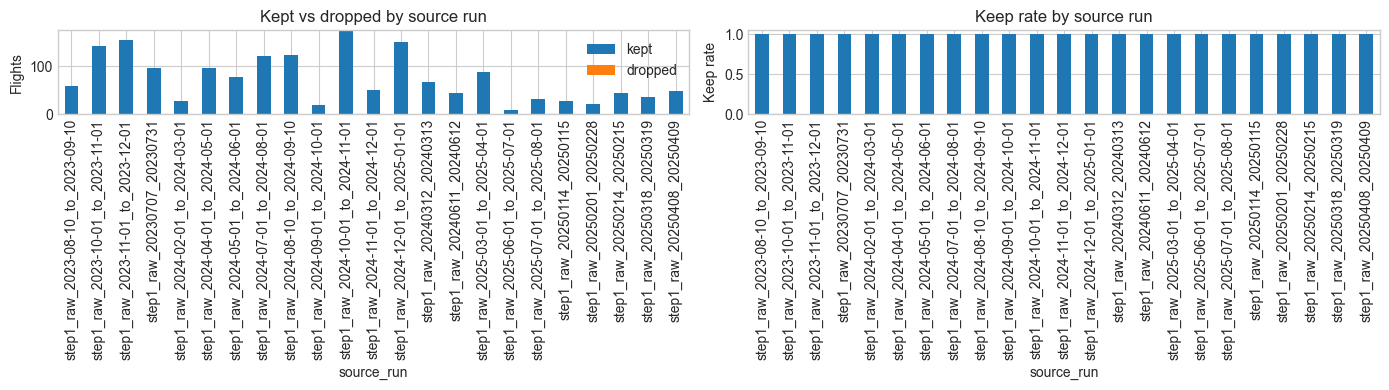

In [8]:
if clean_catalog.empty:
    print("No saved Step 2 outputs found yet.")
else:
    by_run = (
        clean_catalog.groupby("source_run")
        .agg(
            flights=("segment_id", "count"),
            kept=("step2_keep", "sum"),
        )
        .reset_index()
    )
    by_run["dropped"] = by_run["flights"] - by_run["kept"]
    by_run["keep_rate"] = by_run["kept"] / by_run["flights"]
    display(by_run.sort_values(["keep_rate", "flights"], ascending=[False, False]).reset_index(drop=True))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    by_run.set_index("source_run")[["kept", "dropped"]].plot(kind="bar", stacked=True, ax=axes[0], title="Kept vs dropped by source run")
    axes[0].set_ylabel("Flights")
    by_run.set_index("source_run")["keep_rate"].plot(kind="bar", ax=axes[1], title="Keep rate by source run")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_ylabel("Keep rate")
    plt.tight_layout()

## Drop Diagnosis
This table explains why flights were removed from the cleaned dataset.
Use it to verify that the rejection logic matches the expected failure modes.


In [9]:
if drop_reasons.empty:
    print("No dropped flights in the loaded Step 2 outputs.")
else:
    drop_counts = (
        drop_reasons.groupby("drop_reason")
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
    )
    display(drop_counts)
    display(
        clean_catalog.loc[~clean_catalog["step2_keep"], [
            "segment_id",
            "source_run",
            "drop_reason",
            "before_anchor_speed_kts_after_clean",
            "after_anchor_speed_kts_after_clean",
            "max_adsc_speed_kts_after_clean",
        ]].sort_values("drop_reason")
    )

,drop_reason,count
0,implausible_anchor_speed_after_clean,346


,segment_id,source_run,drop_reason,before_anchor_speed_kts_after_clean,after_anchor_speed_kts_after_clean,max_adsc_speed_kts_after_clean


## Cleaning Actions and Issue Mix
These summaries show which repairs were applied and which issues were most common.
They help justify the final dataset shape instead of treating the cleaner as a black box.


metric,value
flights_with_duplicate_cleanup,64
flights_with_spike_cleanup,0
flights_with_missing_key_cleanup,0
flights_with_sort_fix,0


,issue_type,count
2,implausible_section_speed_after_clean,6349
1,implausible_anchor_speed_after_clean,352
0,duplicate_exact_count,178
3,isolated_spike_removed_count,13


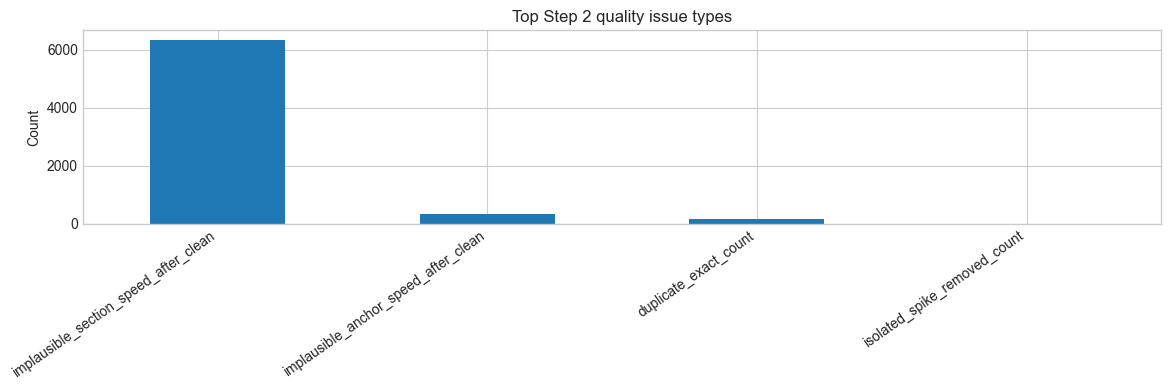

In [10]:
if clean_catalog.empty:
    print("No saved Step 2 outputs found yet.")
else:
    action_summary = [
        {"metric": "flights_with_duplicate_cleanup", "value": int(clean_catalog["quality_flag_any_duplicates_removed"].sum()) if "quality_flag_any_duplicates_removed" in clean_catalog.columns else None},
        {"metric": "flights_with_spike_cleanup", "value": int(clean_catalog["quality_flag_any_spike_removed"].sum()) if "quality_flag_any_spike_removed" in clean_catalog.columns else None},
        {"metric": "flights_with_missing_key_cleanup", "value": int(clean_catalog["quality_flag_any_missing_key_values_removed"].sum()) if "quality_flag_any_missing_key_values_removed" in clean_catalog.columns else None},
        {"metric": "flights_with_sort_fix", "value": int(clean_catalog["quality_flag_any_sort_fix"].sum()) if "quality_flag_any_sort_fix" in clean_catalog.columns else None},
    ]
    display(pd.DataFrame(action_summary).style.hide(axis="index"))

    if not quality_issues.empty:
        issue_counts = (
            quality_issues.groupby("issue_type")
            .size()
            .reset_index(name="count")
            .sort_values("count", ascending=False)
        )
        display(issue_counts)

        ax = issue_counts.head(10).plot(
            kind="bar",
            x="issue_type",
            y="count",
            legend=False,
            title="Top Step 2 quality issue types",
            figsize=(12, 4),
        )
        ax.set_ylabel("Count")
        ax.set_xlabel("")
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()

## Quality Profile of Kept Flights
This section checks the flights that survived cleaning.
The goal is to confirm stable timing, geometry, and continuity before reconstruction starts.


,segment_id,source_run,gap_duration_minutes,adsc_point_count_step1,before_anchor_speed_kts_after_clean,after_anchor_speed_kts_after_clean
0,20230708_0101e0_115103_124631,step1_raw_20230707_20230731,55.466667,5,538.108541,483.938796
1,20230708_040203_105633_115102,step1_raw_20230707_20230731,54.483333,5,549.771839,486.526336
2,20230708_3965b0_114354_124236,step1_raw_20230707_20230731,58.700000,6,577.820497,483.194940
3,20230708_4005bb_132246_150522,step1_raw_20230707_20230731,102.600000,8,516.463555,474.696010
4,20230708_4005be_135507_151954,step1_raw_20230707_20230731,84.783333,8,528.353409,464.808461
5,20230708_4006c2_143857_154752,step1_raw_20230707_20230731,68.916667,11,537.569310,476.906456
6,20230708_400772_152055_161044,step1_raw_20230707_20230731,49.816667,6,489.534190,473.764753
7,20230708_4b1885_133319_150945,step1_raw_20230707_20230731,96.433333,6,504.084801,450.912190
8,20230708_4bb18f_125053_134938,step1_raw_20230707_20230731,58.750000,6,554.118274,475.564906
9,20230708_70209e_134512_145123,step1_raw_20230707_20230731,66.183333,6,582.776389,481.964751


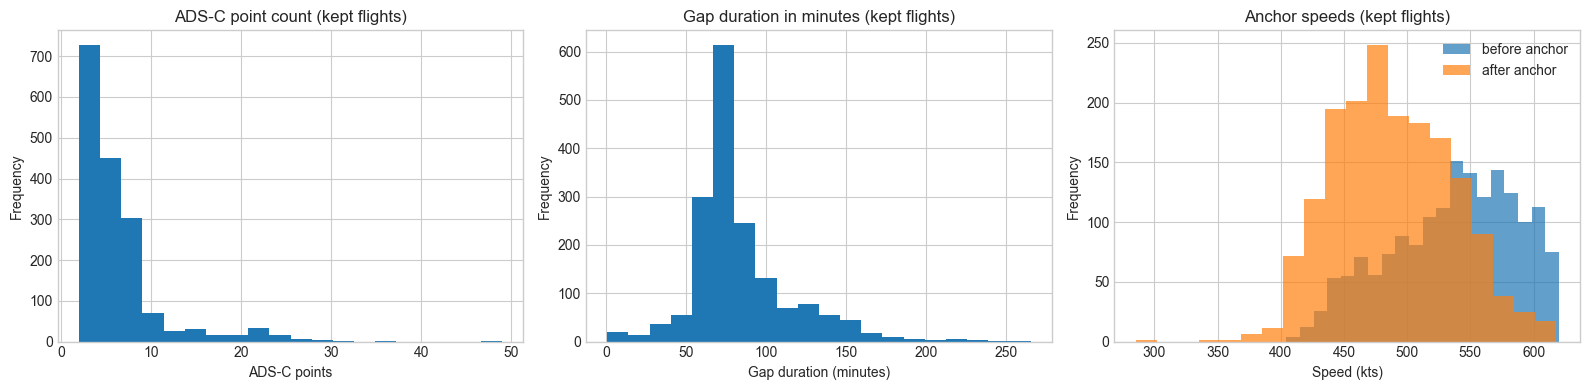

In [11]:
if clean_catalog.empty:
    print("No saved Step 2 outputs found yet.")
else:
    kept_catalog = clean_catalog.loc[clean_catalog["step2_keep"]].copy()
    if kept_catalog.empty:
        print("No kept flights in the loaded Step 2 outputs.")
    else:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        kept_catalog["adsc_point_count_step1"].plot(kind="hist", bins=20, ax=axes[0], title="ADS-C point count (kept flights)")
        axes[0].set_xlabel("ADS-C points")

        kept_catalog["gap_duration_minutes"].plot(kind="hist", bins=20, ax=axes[1], title="Gap duration in minutes (kept flights)")
        axes[1].set_xlabel("Gap duration (minutes)")

        kept_catalog["before_anchor_speed_kts_after_clean"].plot(kind="hist", bins=20, ax=axes[2], alpha=0.7, label="before anchor")
        kept_catalog["after_anchor_speed_kts_after_clean"].plot(kind="hist", bins=20, ax=axes[2], alpha=0.7, label="after anchor")
        axes[2].set_title("Anchor speeds (kept flights)")
        axes[2].set_xlabel("Speed (kts)")
        axes[2].legend()

        plt.tight_layout()

        display(
            kept_catalog[[
                "segment_id",
                "source_run",
                "gap_duration_minutes",
                "adsc_point_count_step1",
                "before_anchor_speed_kts_after_clean",
                "after_anchor_speed_kts_after_clean",
            ]].head(10)
        )

## Example Cleaned Trajectory Verification
This example verifies that a kept flight has the expected cleaned and standardized outputs on disk.
It is a quick integrity check for the saved per-flight artifacts.


Example segment_id: 20230708_0101e0_115103_124631
Clean stitched path: C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step2_clean\flights\20230708_0101e0_115103_124631\stitched_clean.parquet
Standardized path : C:\Users\ANTOINE\OneDrive\Desktop\AeroEngineering - Final Version\artifacts\step2_clean\flights\20230708_0101e0_115103_124631\stitched_standardized_60s.parquet


metric,value
clean_rows,8583
standardized_rows,379
standardized_time_step_seconds_unique,[60.0]
time_start,2023-07-08 10:52:00
time_end,2023-07-08 17:10:00


,timestamp,source_section,latitude,longitude
0,2023-07-08 10:52:00,stitched,55.383087,-0.784392
1,2023-07-08 10:53:00,stitched,55.447300,-0.985250
2,2023-07-08 10:54:00,stitched,55.498135,-1.200943
3,2023-07-08 10:55:00,stitched,55.544678,-1.419567
4,2023-07-08 10:56:00,stitched,55.590820,-1.638627
5,2023-07-08 10:57:00,stitched,55.636093,-1.855774
6,2023-07-08 10:58:00,stitched,55.681320,-2.074668
7,2023-07-08 10:59:00,stitched,55.726194,-2.295542
8,2023-07-08 11:00:00,stitched,55.770614,-2.516859
9,2023-07-08 11:01:00,stitched,55.815033,-2.738176


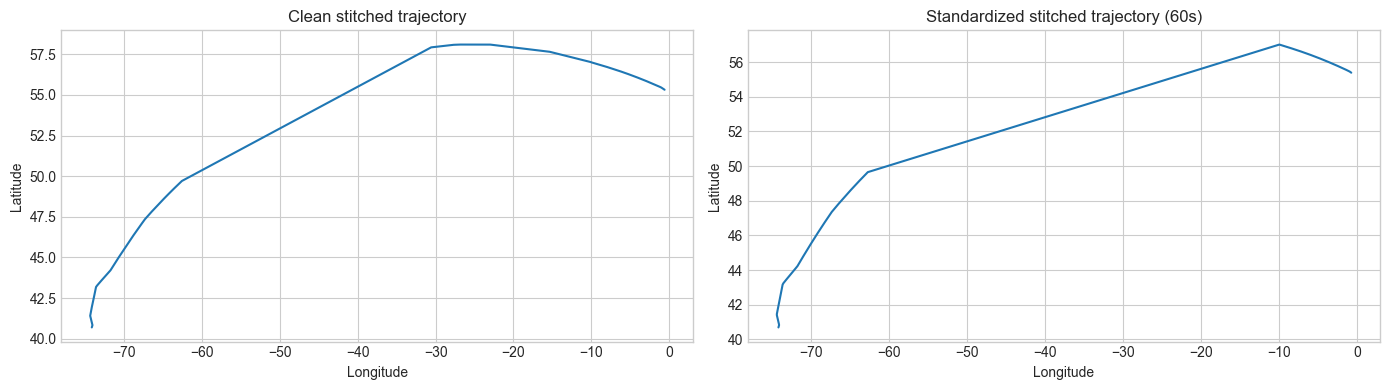

In [12]:
if clean_catalog.empty:
    print("No saved Step 2 outputs found yet.")
else:
    kept_catalog = clean_catalog.loc[clean_catalog["step2_keep"]].copy()
    if kept_catalog.empty:
        print("No kept flights available for example verification.")
    else:
        eligible_examples = kept_catalog.loc[
            kept_catalog["clean_stitched_path"].notna()
            & kept_catalog["standardized_stitched_path"].notna()
        ].copy()
        if eligible_examples.empty:
            print("No kept flights with saved cleaned trajectory files were found.")
        else:
            eligible_examples["clean_exists"] = eligible_examples["clean_stitched_path"].map(lambda value: Path(value).exists())
            eligible_examples["standardized_exists"] = eligible_examples["standardized_stitched_path"].map(lambda value: Path(value).exists())
            eligible_examples = eligible_examples.loc[
                eligible_examples["clean_exists"] & eligible_examples["standardized_exists"]
            ].copy()

            if eligible_examples.empty:
                print("No kept flights with existing cleaned trajectory files were found.")
            else:
                example_row = eligible_examples.iloc[0]
                stitched_path = Path(example_row["clean_stitched_path"])
                standardized_path = Path(example_row["standardized_stitched_path"])

                print(f"Example segment_id: {example_row['segment_id']}")
                print(f"Clean stitched path: {stitched_path}")
                print(f"Standardized path : {standardized_path}")

                stitched_clean = pd.read_parquet(stitched_path)
                stitched_standardized = pd.read_parquet(standardized_path)

                example_summary = {
                    "clean_rows": int(len(stitched_clean)),
                    "standardized_rows": int(len(stitched_standardized)),
                    "standardized_time_step_seconds_unique": sorted(
                        stitched_standardized["timestamp"].sort_values().diff().dropna().dt.total_seconds().unique().tolist()
                    )[:10],
                    "time_start": str(stitched_standardized["timestamp"].min()),
                    "time_end": str(stitched_standardized["timestamp"].max()),
                }
                display(pd.DataFrame(example_summary.items(), columns=["metric", "value"]).style.hide(axis="index"))

                fig, axes = plt.subplots(1, 2, figsize=(14, 4))
                axes[0].plot(stitched_clean["longitude"], stitched_clean["latitude"])
                axes[0].set_title("Clean stitched trajectory")
                axes[0].set_xlabel("Longitude")
                axes[0].set_ylabel("Latitude")

                axes[1].plot(stitched_standardized["longitude"], stitched_standardized["latitude"])
                axes[1].set_title("Standardized stitched trajectory (60s)")
                axes[1].set_xlabel("Longitude")
                axes[1].set_ylabel("Latitude")

                plt.tight_layout()

                display(stitched_standardized[["timestamp", "source_section", "latitude", "longitude"]].head(10))

## Final Notebook Guide
Keep `BUILD_FROM_SOURCE = False` for final review runs.
Turn it on only when you intentionally want to rebuild Step 2 from the saved Step 1 master catalog.
